[전체 방문 여부 분포]
reserve_visited_flag
예      126
아니오     74
Name: count, dtype: int64

[미방문자 수]
74

[미방문자 내 인지 여부]
reserve_awareness_flag
아니오    55
예      19
Name: count, dtype: int64


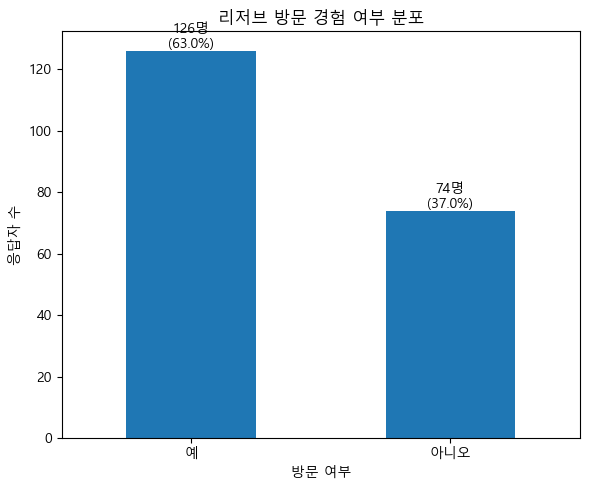


[미방문 이유 - 원본]
                                     건수  비율(%)
reserve_nonvisit_reason                       
리저브 매장 존재여부 미인지(몰랐음)                 39   52.7
커피 취향/관심 낮음(단순 카페인 수혈 - 일반 매장으로 충분)  18   24.3
접근성 불편                                9   12.2
가격 부담                                 6    8.1
매장 분위기/인테리어 불만족                       2    2.7


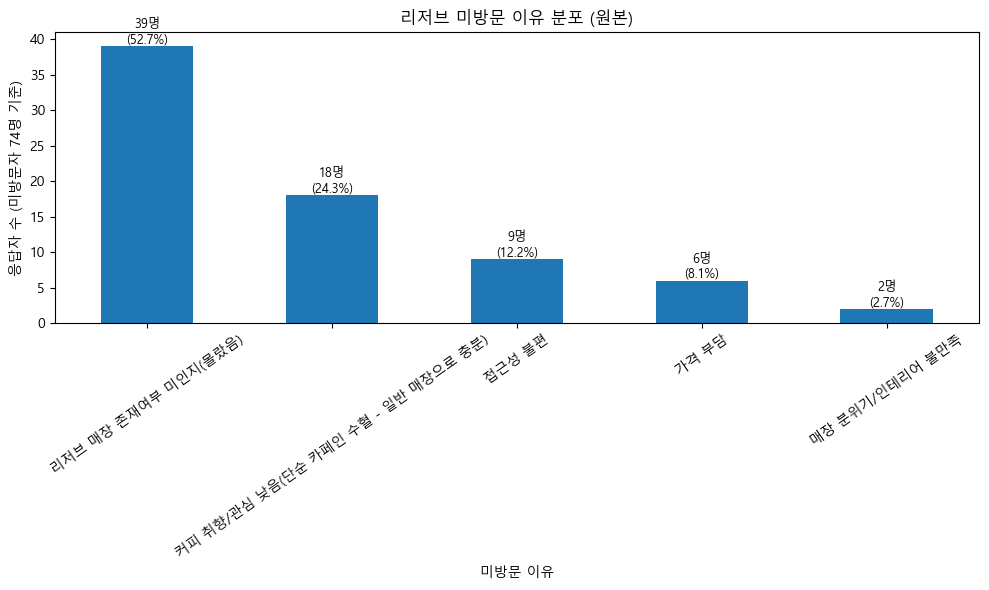


[미방문 이유 - 통합 카테고리]


,건수,비율(%)
nonvisit_reason_grouped,,
인지/정보 부족,39,52.7
관심/니즈 낮음,18,24.3
접근성,9,12.2
가격,6,8.1
기타 경험요인,2,2.7


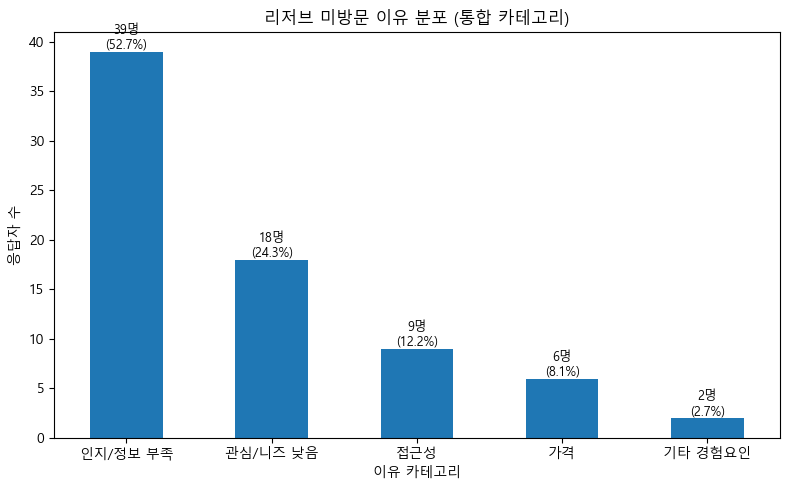


[핵심 수치] 미방문자 74명 중 '몰랐음' 응답: 39명 (52.7%)


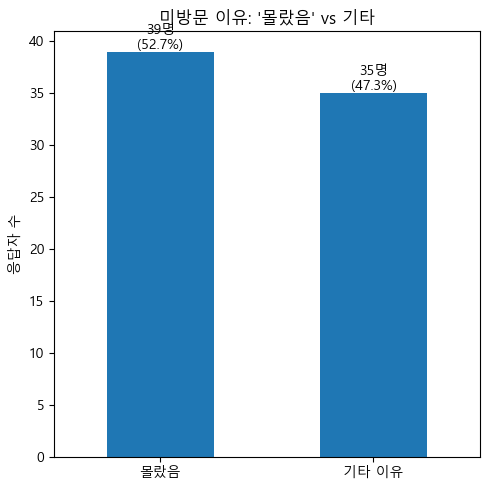


[인지 경로 분포 - 인지자(aware) 기준]


,건수,비율(%)
reserve_awareness_channel,,
"스타벅스 앱 / 매장(포스터, 이벤트)",68,51.9
"지인 추천(친구, 가족, 동료 등)",23,17.6
네이버 지도 / 플레이스,22,16.8
"SNS(인스타, 페이스북 등)",13,9.9
뉴스 / 기사,3,2.3
유튜브 / 블로그,2,1.5


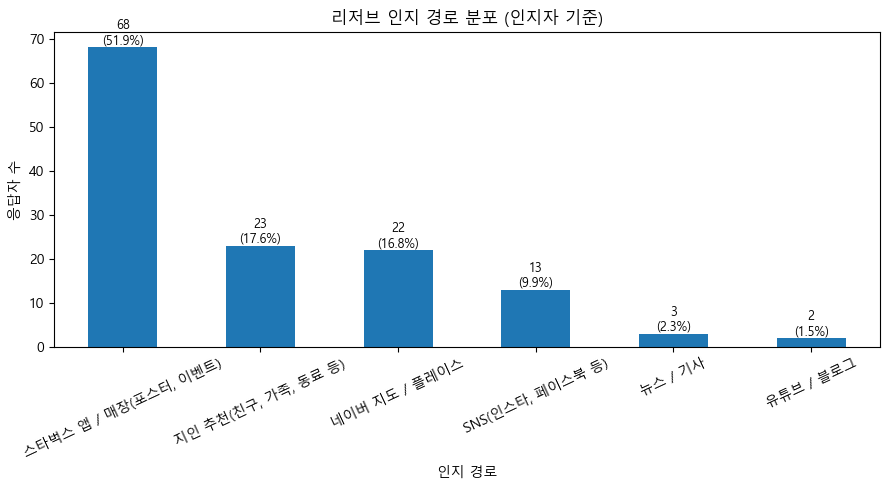


[미방문자 개선 필요 항목]


,건수,비율(%)
improve_grouped,,
접근성 개선,39,52.7
가격 개선,28,37.8
혼잡/대기 개선,2,2.7
서비스 부담 완화,5,6.8


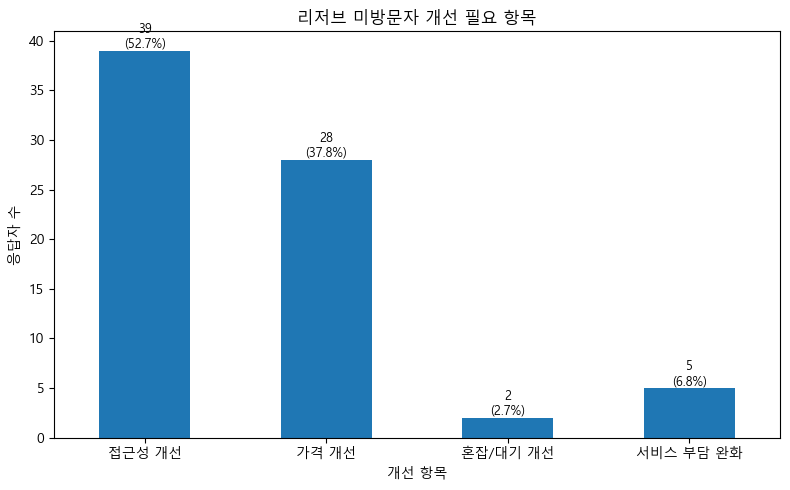

In [2]:
# =========================================
# H4. 가설 데이터 EDA
# 목적:
# - 리저브 미방문 집단(74명)의 이유/경로/개선요구를 시각적으로 확인
# - H4 가설(인지 장벽 집중)과 B안(인지 개선 방안)의 논리 연결
# =========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import platform

# -----------------------------------------
# 0. 한글 폰트 설정 (그래프 한글 깨짐 방지)
# -----------------------------------------
if platform.system() == "Windows":
    plt.rcParams["font.family"] = "Malgun Gothic"
elif platform.system() == "Darwin":
    plt.rcParams["font.family"] = "AppleGothic"
else:
    plt.rcParams["font.family"] = "NanumGothic"
plt.rcParams["axes.unicode_minus"] = False

# -----------------------------------------
# 1. 데이터 로드
# -----------------------------------------
# local_path = r"C:\Users\user\Desktop\데이터 분석 7기 자료\파이널프로젝트\멋사 Final_Project_env\data\survey_h4_refined.csv"
# nonvisit_path = r"C:\Users\user\Desktop\데이터 분석 7기 자료\파이널프로젝트\멋사 Final_Project_env\data\survey_h4_nonvisit.csv"

# 업로드 파일/테스트용
# (전처리 저장 전이면 survey_response.csv 바로 써도 되지만, 전처리 저장본 권장)
local_path = r"C:\Users\user\Desktop\데이터 분석 7기 자료\파이널프로젝트\멋사 Final_Project_env\data\survey_response.csv"
df_raw = pd.read_csv(local_path, encoding="utf-8-sig")

# 전처리 안 거쳤을 때 대비 간단 재정리
df = df_raw.copy()
for c in ["reserve_awareness_flag", "reserve_visited_flag", "reserve_nonvisit_reason", "reserve_awareness_channel", "reserve_improvement"]:
    df[c] = df[c].astype(str).str.strip()
df = df.replace({"nan": np.nan})

df["reserve_awareness_flag"] = df["reserve_awareness_flag"].replace({"Yes":"예","No":"아니오"})
df["reserve_visited_flag"] = df["reserve_visited_flag"].replace({"Yes":"예","No":"아니오"})

reason_map = {
    "리저브 매장 존재여부 미인지(몰랐음)": "인지/정보 부족",
    "접근성 불편": "접근성",
    "가격 부담": "가격",
    "커피 취향/관심 낮음(단순 카페인 수혈 - 일반 매장으로 충분)": "관심/니즈 낮음",
    "매장 분위기/인테리어 불만족": "기타 경험요인"
}
df["nonvisit_reason_grouped"] = df["reserve_nonvisit_reason"].replace(reason_map)

improve_map = {
    "매장 접근성 개선(추가 매장 확대)": "접근성 개선",
    "가격 인하": "가격 개선",
    "혼잡 및 대기 개선(예약/대기 시스템)": "혼잡/대기 개선",
    "리저브 바(Bar) 1:1 서비스 부담 완화": "서비스 부담 완화"
}
df["improve_grouped"] = df["reserve_improvement"].replace(improve_map)

# H4 서브셋
nonvisit = df[df["reserve_visited_flag"] == "아니오"].copy()

# =========================================
# Step A. 데이터 신뢰성/구성 확인
# =========================================
print("[전체 방문 여부 분포]")
print(df["reserve_visited_flag"].value_counts(dropna=False))

print("\n[미방문자 수]")
print(len(nonvisit))

print("\n[미방문자 내 인지 여부]")
print(nonvisit["reserve_awareness_flag"].value_counts(dropna=False))

# 시각화: 방문 여부 분포
visit_ct = df["reserve_visited_flag"].value_counts().reindex(["예", "아니오"], fill_value=0)
visit_pct = (visit_ct / visit_ct.sum() * 100).round(1)

ax = visit_ct.plot(kind="bar", figsize=(6,5), rot=0)
plt.title("리저브 방문 경험 여부 분포")
plt.xlabel("방문 여부")
plt.ylabel("응답자 수")

for i, (cnt, pct) in enumerate(zip(visit_ct.values, visit_pct.values)):
    ax.text(i, cnt, f"{cnt}명\n({pct}%)", ha="center", va="bottom", fontsize=10)

plt.tight_layout()
plt.show()

# =========================================
# Step B-1. 미방문 이유 분포 (원본)
# =========================================
reason_ct = nonvisit["reserve_nonvisit_reason"].value_counts(dropna=False)
reason_pct = (reason_ct / reason_ct.sum() * 100).round(1)

print("\n[미방문 이유 - 원본]")
print(pd.DataFrame({"건수": reason_ct, "비율(%)": reason_pct}))

# 그래프 (원본 이유)
plot_reason = nonvisit["reserve_nonvisit_reason"].value_counts().sort_values(ascending=False)
plot_reason_pct = (plot_reason / plot_reason.sum() * 100)

ax = plot_reason.plot(kind="bar", figsize=(10,6), rot=35)
plt.title("리저브 미방문 이유 분포 (원본)")
plt.xlabel("미방문 이유")
plt.ylabel("응답자 수 (미방문자 74명 기준)")

for i, (cnt, pct) in enumerate(zip(plot_reason.values, plot_reason_pct.values)):
    ax.text(i, cnt, f"{cnt}명\n({pct:.1f}%)", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.show()

# =========================================
# Step B-2. 미방문 이유 분포 (통합 카테고리)
# =========================================
group_order = ["인지/정보 부족", "관심/니즈 낮음", "접근성", "가격", "기타 경험요인"]

reason_g_ct = nonvisit["nonvisit_reason_grouped"].value_counts().reindex(group_order, fill_value=0)
reason_g_pct = (reason_g_ct / reason_g_ct.sum() * 100).round(1)

print("\n[미방문 이유 - 통합 카테고리]")
display(pd.DataFrame({"건수": reason_g_ct, "비율(%)": reason_g_pct}))

ax = reason_g_ct.plot(kind="bar", figsize=(8,5), rot=0)
plt.title("리저브 미방문 이유 분포 (통합 카테고리)")
plt.xlabel("이유 카테고리")
plt.ylabel("응답자 수")

for i, (cnt, pct) in enumerate(zip(reason_g_ct.values, reason_g_pct.values)):
    ax.text(i, cnt, f"{cnt}명\n({pct:.1f}%)", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.show()

# =========================================
# Step B-3. '몰랐음' 비율 강조 (H4-1 후보)
# =========================================
n_nonvisit = len(nonvisit)
n_unaware_reason = (nonvisit["reserve_nonvisit_reason"] == "리저브 매장 존재여부 미인지(몰랐음)").sum()
pct_unaware_reason = n_unaware_reason / n_nonvisit * 100

print(f"\n[핵심 수치] 미방문자 {n_nonvisit}명 중 '몰랐음' 응답: {n_unaware_reason}명 ({pct_unaware_reason:.1f}%)")

# 2막대 비교 그래프: 몰랐음 vs 기타
focus_ct = pd.Series({
    "몰랐음": n_unaware_reason,
    "기타 이유": n_nonvisit - n_unaware_reason
})
focus_pct = focus_ct / focus_ct.sum() * 100

ax = focus_ct.plot(kind="bar", figsize=(5,5), rot=0)
plt.title("미방문 이유: '몰랐음' vs 기타")
plt.ylabel("응답자 수")

for i, (cnt, pct) in enumerate(zip(focus_ct.values, focus_pct.values)):
    ax.text(i, cnt, f"{cnt}명\n({pct:.1f}%)", ha="center", va="bottom", fontsize=10)

plt.tight_layout()
plt.show()

# =========================================
# Step B-4. 인지 경로 EDA (B안 근거)
# - 주의: 인지 경로는 리저브를 '안 사람'에게만 의미 있음
# =========================================
aware = df[df["reserve_awareness_flag"] == "예"].copy()
channel_ct = aware["reserve_awareness_channel"].value_counts()
channel_pct = (channel_ct / channel_ct.sum() * 100).round(1)

print("\n[인지 경로 분포 - 인지자(aware) 기준]")
display(pd.DataFrame({"건수": channel_ct, "비율(%)": channel_pct}))

ax = channel_ct.plot(kind="bar", figsize=(9,5), rot=25)
plt.title("리저브 인지 경로 분포 (인지자 기준)")
plt.xlabel("인지 경로")
plt.ylabel("응답자 수")

for i, (cnt, pct) in enumerate(zip(channel_ct.values, channel_pct.values)):
    ax.text(i, cnt, f"{cnt}\n({pct:.1f}%)", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.show()

# =========================================
# Step B-5. 개선 필요 항목 EDA (B안/C안 메시지 설계 근거)
# - 미방문자 중심으로 보는 게 자연스러움
# =========================================
imp_order = ["접근성 개선", "가격 개선", "혼잡/대기 개선", "서비스 부담 완화"]
imp_ct = nonvisit["improve_grouped"].value_counts().reindex(imp_order, fill_value=0)
imp_pct = (imp_ct / imp_ct.sum() * 100).round(1)

print("\n[미방문자 개선 필요 항목]")
display(pd.DataFrame({"건수": imp_ct, "비율(%)": imp_pct}))

ax = imp_ct.plot(kind="bar", figsize=(8,5), rot=0)
plt.title("리저브 미방문자 개선 필요 항목")
plt.xlabel("개선 항목")
plt.ylabel("응답자 수")

for i, (cnt, pct) in enumerate(zip(imp_ct.values, imp_pct.values)):
    ax.text(i, cnt, f"{cnt}\n({pct:.1f}%)", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.show()

In [9]:
# 알고도 안 간 사람 찾기
# 업로드된 survey_response.csv 기준으로는 “알고도 안 간 사람 = 5명”이 아니고, 19명.
# (단, 응답 논리상 “인지(예)”인데 미방문 이유를 “몰랐음”이라고 찍은 사람이 2명 있어서, 엄밀한 ‘알고도’ 집단으로 잡으면 17명도 같이 제시하는 게 안전)

# 아래에 어떻게 찾는지(코드) + 몇 명인지 + **그 사람들이 각각 어떤 이유인지(개별 리스트 + 요약)**까지 한 번에 정리


# reserve_visited_flag == "No" (리저브 방문 X)
# reserve_awareness_flag == "Yes" (리저브 존재 인지 O)

import pandas as pd

df = pd.read_csv(
    r"C:\Users\user\Desktop\데이터 분석 7기 자료\파이널프로젝트\멋사 Final_Project_env\data\survey_response.csv",
    encoding="utf-8-sig"
)

# Yes/No 정리
df["reserve_visited_flag"] = df["reserve_visited_flag"].astype(str).str.strip().replace({"Yes":"예","No":"아니오"})
df["reserve_awareness_flag"] = df["reserve_awareness_flag"].astype(str).str.strip().replace({"Yes":"예","No":"아니오"})

# ✅ 알고도 안 간 사람(기본 정의)
aware_nonvisit = df[(df["reserve_visited_flag"]=="아니오") & (df["reserve_awareness_flag"]=="예")].copy()
print(len(aware_nonvisit))

19


2) “5명”이 아니라 19명인 이유는?

네가 말한 5명은 아마:

다른 버전 데이터였거나,

“알고도 안 감”을 더 강한 조건(예: 특정 답변/결측 제거/필터)으로 잡았거나,

전처리 과정에서 일부가 제외된 케이스일 가능성이 커.

그리고 현재 CSV에서는 논리 불일치 응답 2명이 있어:

인지=예인데 미방문이유=몰랐음

그래서 “알고도”를 엄밀하게 하려면 이 2명을 빼고 17명으로 보는 게 더 자연스러워.

In [10]:
aware_nonvisit_strict = aware_nonvisit[
    aware_nonvisit["reserve_nonvisit_reason"].astype(str).str.strip() != "리저브 매장 존재여부 미인지(몰랐음)"
].copy()
print(len(aware_nonvisit_strict))

17


3) 그럼 “알고도 안 간 사람”들의 이유는 뭐야? (요약)
(A) 기본 정의 19명 기준: 미방문 이유 분포

커피 취향/관심 낮음(일반 매장으로 충분): 8명

접근성 불편: 5명

가격 부담: 4명

(인지=예인데) 몰랐음: 2명 ← 데이터 응답 불일치

(B) 엄밀 정의 17명 기준(‘몰랐음’ 제거): 미방문 이유 분포

커피 취향/관심 낮음: 8명

접근성 불편: 5명

가격 부담: 4명

✅ 즉, “알고도 안 간 사람들”은 인지 문제가 아니라
가격/접근성/관심(니즈) 쪽이 핵심 장벽으로 나타나.

4) 19명 각각 “무슨 이유”인지 (개별 리스트)

아래는 인지 경로 + 미방문 이유 + 개선 희망까지 한 줄씩 정리한 거야.
(개인 식별정보는 없고, 설문 응답 변수만 그대로 요약)



| No | 인지 경로                 | 미방문 이유                  | 개선 희망               |
| -: | :-------------------- | :---------------------- | :------------------ |
|  1 | 스타벅스 앱 / 매장(포스터, 이벤트) | 커피 취향/관심 낮음(일반 매장으로 충분) | 리저브 바 1:1 서비스 부담 완화 |
|  2 | 스타벅스 앱 / 매장(포스터, 이벤트) | 가격 부담                   | 가격 인하               |
|  3 | 스타벅스 앱 / 매장(포스터, 이벤트) | 커피 취향/관심 낮음(일반 매장으로 충분) | 리저브 바 1:1 서비스 부담 완화 |
|  4 | SNS                   | 가격 부담                   | 가격 인하               |
|  5 | 네이버 지도 / 플레이스         | 커피 취향/관심 낮음(일반 매장으로 충분) | 가격 인하               |
|  6 | SNS                   | 가격 부담                   | 매장 접근성 개선(추가 매장 확대) |
|  7 | 네이버 지도 / 플레이스         | 커피 취향/관심 낮음(일반 매장으로 충분) | 가격 인하               |
|  8 | 스타벅스 앱 / 매장(포스터, 이벤트) | 접근성 불편                  | 매장 접근성 개선(추가 매장 확대) |
|  9 | 지인 추천                 | 접근성 불편                  | 매장 접근성 개선(추가 매장 확대) |
| 10 | 스타벅스 앱 / 매장(포스터, 이벤트) | 커피 취향/관심 낮음(일반 매장으로 충분) | 가격 인하               |
| 11 | 스타벅스 앱 / 매장(포스터, 이벤트) | 접근성 불편                  | 매장 접근성 개선(추가 매장 확대) |
| 12 | SNS                   | 접근성 불편                  | 가격 인하               |
| 13 | 유튜브 / 블로그             | 가격 부담                   | 가격 인하               |
| 14 | 지인 추천                 | 커피 취향/관심 낮음(일반 매장으로 충분) | 매장 접근성 개선(추가 매장 확대) |
| 15 | 뉴스 / 기사               | 리저브 매장 존재여부 미인지(몰랐음)    | 매장 접근성 개선(추가 매장 확대) |
| 16 | 지인 추천                 | 접근성 불편                  | 매장 접근성 개선(추가 매장 확대) |
| 17 | 스타벅스 앱 / 매장(포스터, 이벤트) | 리저브 매장 존재여부 미인지(몰랐음)    | 매장 접근성 개선(추가 매장 확대) |
| 18 | 스타벅스 앱 / 매장(포스터, 이벤트) | 커피 취향/관심 낮음(일반 매장으로 충분) | 매장 접근성 개선(추가 매장 확대) |
| 19 | 지인 추천                 | 커피 취향/관심 낮음(일반 매장으로 충분) | 가격 인하               |



주의: 15번/17번은 “인지=예”인데 “몰랐음”을 선택한 케이스라, 발표/분석에서는 “응답 불일치 2건”으로 따로 처리하거나 엄밀 집단(17명)으로 분석하는 게 깔끔해.



5) 

미방문 전체(74명)에서는 “몰랐음”이 1위(52.7%) → 인지 개선(B안) 근거

그런데 “인지하고도 안 간 집단(17명)”을 따로 보면, 장벽은 가격/접근성/관심으로 바뀜 → 서브 방안/보완 근거

발표 문장 예시:

“미방문 전체에서는 ‘몰랐음’이 과반으로 가장 큰 장벽이었지만, 인지하고도 미방문한 집단을 분리해 보면 장벽이 가격/접근성/니즈로 이동합니다. 즉, 인지 개선과 함께 ‘첫 체험 유도/접근성 메시지’가 보완적으로 필요합니다.”